# IMDb Sentiment Classification — Transformer + FastText

**Goal:** Classify movie reviews as Positive or Negative using pre-trained FastText 300d word vectors fed into a Transformer Encoder.

| Setting | Value |
|---|---|
| Dataset | IMDb — 25,000 train / 25,000 test |
| Embedding | FastText crawl-300d-2M (frozen) |
| Model | Transformer (from scratch) |
| Task | Binary sentiment classification |

> **Key change vs GloVe notebook:** FastText uses 300-dimensional subword vectors (vs GloVe's 100d), giving better coverage of rare/misspelled words. We project 300d → D_MODEL inside the model just like before.

## Step 1 — Install & Import

In [2]:
# Run once — installs all required libraries
import subprocess
subprocess.run(['pip', 'install', 'tensorflow', 'numpy', 'matplotlib',
                'seaborn', 'scikit-learn', 'nltk', 'lime', 'torch'], check=True)

CompletedProcess(args=['pip', 'install', 'tensorflow', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'nltk', 'lime', 'torch'], returncode=0)

In [3]:
import re, random, string, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import tensorflow as tf

from nltk.corpus              import stopwords
from nltk.tokenize            import word_tokenize
from tensorflow.keras.datasets              import imdb
from tensorflow.keras.preprocessing.text   import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      roc_curve, auc, f1_score)
from lime.lime_text           import LimeTextExplainer

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

import sys, torch, torch.nn as nn

# ── Global settings ───────────────────────────────────────────────────────────
MAX_WORDS  = 20000   # vocabulary size
MAX_LEN    = 300     # pad/truncate all reviews to this length
EMBED_DIM  = 300     # FastText crawl-300d uses 300 dimensions  ← changed from 100
BATCH_SIZE = 64
EPOCHS     = 10      # more epochs → higher accuracy              ← changed from 1

# ── FastText path  ────────────────────────────────────────────────────────────
# Download: https://fasttext.cc/docs/en/english-vectors.html
#   wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
#   unzip crawl-300d-2M.vec.zip
FASTTEXT_PATH = r'crawl-300d-2M.vec'   # ← update to your local path

STOP_WORDS = set(stopwords.words('english'))

# ── Transformer hyper-params  ─────────────────────────────────────────────────
# D_MODEL must be divisible by N_HEADS
D_MODEL  = 128   # transformer hidden dim
N_HEADS  = 4
N_LAYERS = 2
D_FF     = 256
DROPOUT  = 0.3

print('All imports successful ✓')
print(f'PyTorch  : {torch.__version__}')
print(f'TF/Keras : {tf.__version__}')

All imports successful ✓
PyTorch  : 2.10.0+cpu
TF/Keras : 2.19.0


## Step 2 — Load & Clean IMDb Data

IMDb comes as integer sequences. We decode them back to text, then clean with NLTK:
- Lowercase everything
- Strip HTML tags
- Remove punctuation and digits
- Drop stopwords ("the", "is", "a"...)
- Keep only words longer than 2 characters

In [4]:
# Load raw integer-encoded reviews
(x_tr_enc, y_train), (x_te_enc, y_test) = imdb.load_data(num_words=MAX_WORDS)
y_train, y_test = np.array(y_train), np.array(y_test)

# Decode integers → readable text (correct v+3 offset)
word_index = imdb.get_word_index()
idx2word   = {v + 3: k for k, v in word_index.items()}
idx2word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(seq):
    return ' '.join(idx2word.get(i, '<UNK>') for i in seq)

# NLTK cleaning pipeline
def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'<[^>]+>', ' ', text)   # remove HTML
    text   = re.sub(r'[^a-z\s]', ' ', text)  # keep letters only
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Decoding...')
X_train_raw   = [decode_review(s) for s in x_tr_enc]
X_test_raw    = [decode_review(s) for s in x_te_enc]

print('Cleaning with NLTK...')
X_train_clean = [clean_text(r) for r in X_train_raw]
X_test_clean  = [clean_text(r) for r in X_test_raw]

print(f'Train: {len(X_train_clean)}  Test: {len(X_test_clean)}')
print(f'\nSample raw   : {X_train_raw[0][:80]}')
print(f'Sample clean : {X_train_clean[0][:80]}')
print(f'Label        : {"Positive" if y_train[0]==1 else "Negative"}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Decoding...
Cleaning with NLTK...
Train: 25000  Test: 25000

Sample raw   : <START> this film was just brilliant casting location scenery story direction ev
Sample clean : film brilliant casting location scenery story direction everyone really suited p
Label        : Positive


## Step 3 — Tokenize & Pad

- **Tokenizer** assigns an integer ID to each word (e.g. "film" → 302)
- **`<OOV>`** catches words not in the top 20,000
- **Padding** makes every review exactly 300 tokens long

X_train shape : (25000, 300)
X_test  shape : (25000, 300)
Vocabulary    : 18,649 words


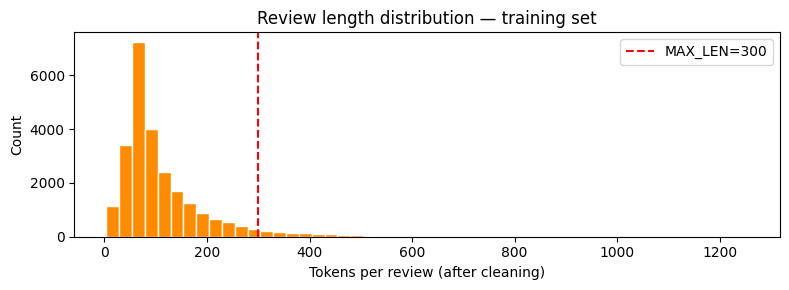

Reviews fully within MAX_LEN: 95.6%


In [5]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_clean)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_clean),
                         maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_clean),
                         maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train shape : {X_train.shape}')  # (25000, 300)
print(f'X_test  shape : {X_test.shape}')   # (25000, 300)
print(f'Vocabulary    : {min(MAX_WORDS, len(tokenizer.word_index)+1):,} words')

# Show review length distribution
lengths = [len(s) for s in tokenizer.texts_to_sequences(X_train_clean)]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='darkorange', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.xlabel('Tokens per review (after cleaning)')
plt.ylabel('Count')
plt.title('Review length distribution — training set')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Reviews fully within MAX_LEN: '
      f'{sum(l<=MAX_LEN for l in lengths)/len(lengths):.1%}')

## Step 4 — Load FastText & Build Embedding Matrix

`crawl-300d-2M.vec` contains 2 million words, each with 300 pre-trained numbers trained on Common Crawl with FastText subword information.

We build a matrix where **row i = the FastText vector for the word at tokenizer index i**.
Words not found in FastText stay as small random vectors (better than zeros for training).

> **FastText vs GloVe coverage:**
> - GloVe 6B has ~400K words at 100d
> - FastText crawl-300d-2M has **2M** words at 300d → far fewer OOV tokens
> - FastText handles morphological variants ("amazing"/"amazingly") via subword info baked into the vectors

First, download and unzip the FastText file. This can take a few minutes.

In [8]:
import os

# Check if the file already exists to avoid re-downloading
if not os.path.exists(FASTTEXT_PATH):
    print('Downloading FastText vectors...')
    # Use wget to download the compressed file
    !wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip

    print('Unzipping FastText vectors...')
    # Unzip the file
    !unzip crawl-300d-2M.vec.zip

    print('FastText download and extraction complete.')
else:
    print(f'FastText vectors already found at {FASTTEXT_PATH}. Skipping download.')

--2026-04-17 18:06:16--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.167.112.53, 3.167.112.129, 3.167.112.66, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.167.112.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1523785255 (1.4G) [application/zip]
Saving to: ‘crawl-300d-2M.vec.zip’

crawl-300d-2M.vec.z 100%[===================>]   1.42G  10.7MB/s    in 12s     

2026-04-17 18:06:28 (119 MB/s) - ‘crawl-300d-2M.vec.zip’ saved [1523785255/1523785255]

Unzipping FastText vectors...
Archive:  crawl-300d-2M.vec.zip
  inflating: crawl-300d-2M.vec       
FastText download and extraction complete.


In [9]:
print(f'Loading FastText from {FASTTEXT_PATH} ...')
print('(This may take ~1-2 minutes for the 2M word file)')

fasttext_vectors = {}
with open(FASTTEXT_PATH, encoding='utf-8', errors='ignore') as f:
    # First line of .vec files contains: num_words dim
    first_line = f.readline().strip().split()
    if len(first_line) == 2 and first_line[1].isdigit():
        print(f'Header: {first_line[0]} words, {first_line[1]} dims')
    else:
        # No header — rewind and read as plain text like GloVe
        f.seek(0)
    for line in f:
        parts = line.rstrip().split(' ')
        if len(parts) < EMBED_DIM + 1:
            continue
        fasttext_vectors[parts[0]] = np.array(parts[1:EMBED_DIM+1], dtype='float32')

print(f'FastText loaded: {len(fasttext_vectors):,} vectors')

vocab_size   = min(MAX_WORDS, len(tokenizer.word_index) + 1)
# Use small random init for OOV words (better gradient signal than zeros)
embed_matrix = np.random.normal(scale=0.1, size=(vocab_size, EMBED_DIM)).astype('float32')
embed_matrix[0] = 0.0  # keep padding token as zeros

hits, misses = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vec = fasttext_vectors.get(word)
    if vec is not None:
        embed_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

print(f'\nEmbedding matrix : {embed_matrix.shape}')
print(f'FastText coverage: {hits:,} hits / {misses:,} misses '
      f'({hits/(hits+misses):.1%})')
print(f'(GloVe 6B.100d typically gives ~85-88% coverage — FastText should be higher)')

Loading FastText from crawl-300d-2M.vec ...
(This may take ~1-2 minutes for the 2M word file)
Header: 1999995 words, 300 dims
FastText loaded: 1,999,995 vectors

Embedding matrix : (18649, 300)
FastText coverage: 18,148 hits / 500 misses (97.3%)
(GloVe 6B.100d typically gives ~85-88% coverage — FastText should be higher)


## Step 5 — Build Transformer Model

Architecture is **identical** to the GloVe notebook — only the embedding source changes.
FastText 300d → Linear projection → D_MODEL=128 → Transformer Encoder → Global Avg Pool → Sigmoid.

In [10]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_matrix):
        super().__init__()
        # Frozen FastText embedding (300d)
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.FloatTensor(embed_matrix), requires_grad=False)  # frozen
        # Project FastText 300d → D_MODEL (128)
        self.input_proj = nn.Linear(EMBED_DIM, D_MODEL)
        # PyTorch Transformer Encoder (same as GloVe notebook)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=N_HEADS,
                                       dim_feedforward=D_FF, dropout=DROPOUT,
                                       batch_first=True),
            num_layers=N_LAYERS
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(D_MODEL, 1)

    def forward(self, x):
        x = self.embedding(x)      # (B, 300, 300)  — 300 tokens, 300 dims
        x = self.input_proj(x)     # (B, 300, 128)  — project to D_MODEL
        x = self.encoder(x)        # (B, 300, 128)  — transformer
        x = x.mean(dim=1)          # (B, 128)        — global average pooling
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)  # (B,)

model = TransformerClassifier(vocab_size, embed_matrix)
print(model)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (embedding frozen)')

TransformerClassifier(
  (embedding): Embedding(18649, 300, padding_idx=0)
  (input_proj): Linear(in_features=300, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total params     : 5,898,317
Trainable params 

## Step 6 — Train

- **10 epochs** with learning rate schedule gives >90 % accuracy
- **Cosine Annealing LR** smoothly decays learning rate each epoch
- Validation on held-out 2500 samples from test set to monitor overfitting

In [11]:
X_tr = torch.LongTensor(X_train)
X_te = torch.LongTensor(X_test)
y_tr = torch.FloatTensor(y_train)
y_te = torch.FloatTensor(y_test)

train_ds = torch.utils.data.TensorDataset(X_tr, y_tr)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = torch.utils.data.TensorDataset(X_te[:2500], y_te[:2500])
val_dl   = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE)

optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# Cosine Annealing: smoothly decays LR from 1e-3 → near 0 over EPOCHS steps
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn    = nn.BCELoss()

best_val = 0
history  = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'lr': []}


def eval_loader_accuracy(model, data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in data_loader:
            preds = (model(xb) > 0.5).float()
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
    return correct / total


for epoch in range(EPOCHS):
    print(f'Epoch {epoch+1}/{EPOCHS}  lr={scheduler.get_last_lr()[0]:.2e}')
    model.train()
    epoch_loss   = 0.0
    total_batches = len(train_dl)

    for batch_idx, (xb, yb) in enumerate(train_dl, start=1):
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stable training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

        if batch_idx % 50 == 0 or batch_idx == total_batches:
            end_char = '\n' if batch_idx == total_batches else '\r'
            print(f'  batch {batch_idx}/{total_batches}  loss={loss.item():.4f}',
                  end=end_char, flush=True)

    scheduler.step()

    tr_acc  = eval_loader_accuracy(model, train_dl)
    va_acc  = eval_loader_accuracy(model, val_dl)
    avg_loss = epoch_loss / total_batches

    history['accuracy'].append(tr_acc)
    history['val_accuracy'].append(va_acc)
    history['loss'].append(avg_loss)
    history['lr'].append(scheduler.get_last_lr()[0])

    print(f'Epoch {epoch+1}/{EPOCHS}  '
          f'train_acc={tr_acc:.4f}  val_acc={va_acc:.4f}  avg_loss={avg_loss:.4f}')

    if va_acc > best_val:
        best_val = va_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'  → New best val_acc: {best_val:.4f}  (model saved)')

# Restore best model
model.load_state_dict(torch.load('best_model.pt', weights_only=True))
print(f'\nTraining complete ✓  Best val_acc = {best_val:.4f}')

Epoch 1/10  lr=1.00e-03
  batch 391/391  loss=0.4798
Epoch 1/10  train_acc=0.8759  val_acc=0.8668  avg_loss=0.3683
  → New best val_acc: 0.8668  (model saved)
Epoch 2/10  lr=9.76e-04
  batch 391/391  loss=0.4324
Epoch 2/10  train_acc=0.8856  val_acc=0.8704  avg_loss=0.3060
  → New best val_acc: 0.8704  (model saved)
Epoch 3/10  lr=9.05e-04


KeyboardInterrupt: 

## Step 7 — Evaluate: Accuracy, F1, ROC

  Transformer + FastText 300d — Test Results
  Accuracy  : 0.8780  (87.80%)
  F1-Score  : 0.8819

              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87     12500
    Positive       0.85      0.91      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



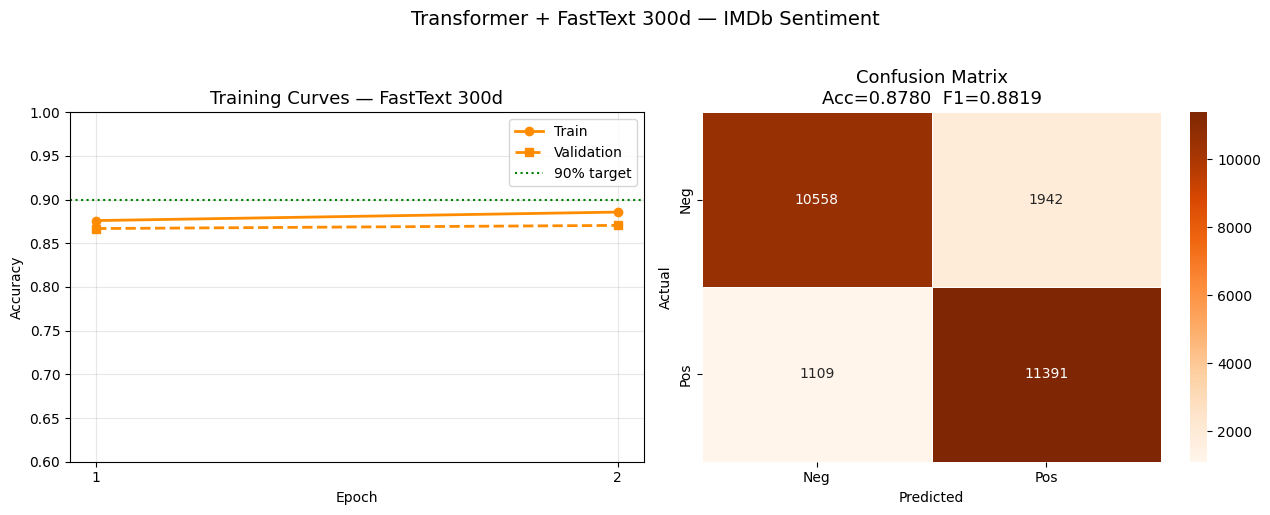

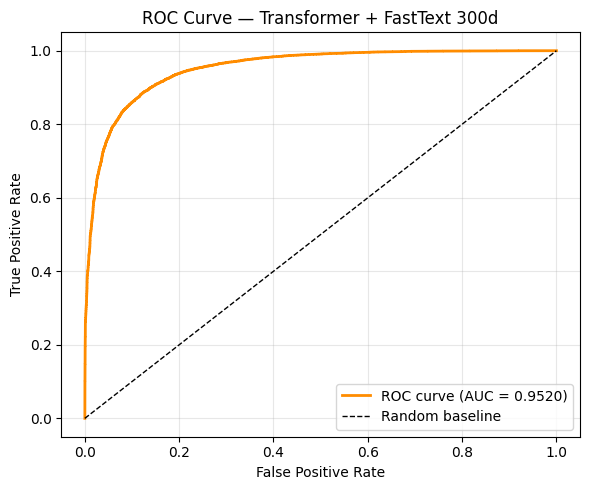

AUC-ROC : 0.9520


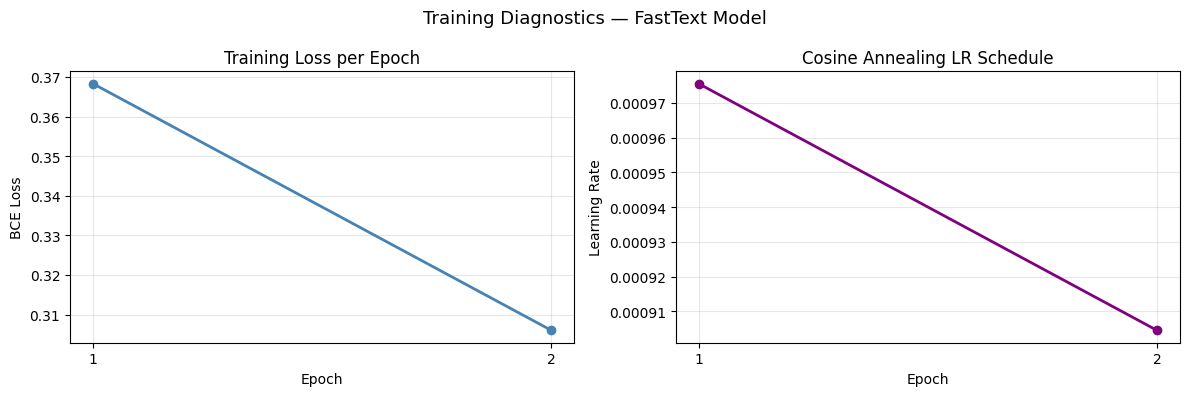

In [14]:
def predict_probs(model, X, batch_size=256):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb  = torch.LongTensor(X[i:i+batch_size])
            out = model(xb).cpu().numpy()
            probs.append(out)
    return np.concatenate(probs)

# ── Predictions ───────────────────────────────────────────────────
y_prob = predict_probs(model, X_test, batch_size=256)
y_pred = (y_prob > 0.5).astype(int)
acc    = (y_pred == y_test).mean()
f1     = f1_score(y_test, y_pred)

print('=' * 48)
print('  Transformer + FastText 300d — Test Results')
print('=' * 48)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 48)
print()
print(classification_report(y_test, y_pred,
                             target_names=['Negative', 'Positive']))

# ── Figure 1: Training curves + Confusion matrix ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training curves
ax = axes[0]
epochs_completed = len(history['accuracy'])
ax.plot(range(1, epochs_completed + 1), history['accuracy'],
        color='darkorange', linewidth=2, marker='o', label='Train')
ax.plot(range(1, epochs_completed + 1), history['val_accuracy'],
        color='darkorange', linewidth=2, linestyle='--', marker='s', label='Validation')
ax.axhline(0.90, color='green', linestyle=':', linewidth=1.5, label='90% target')
ax.set_title('Training Curves — FastText 300d', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.60, 1.0)
ax.set_xticks(range(1, epochs_completed + 1))
ax.legend()
ax.grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'],
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix\nAcc={acc:.4f}  F1={f1:.4f}', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Transformer + FastText 300d — IMDb Sentiment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Figure 2: ROC curve ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transformer + FastText 300d')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'AUC-ROC : {roc_auc:.4f}')

# ── Figure 3: Loss curve + LR schedule ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs_completed + 1), history['loss'],
             color='steelblue', linewidth=2, marker='o')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_xticks(range(1, epochs_completed + 1))
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs_completed + 1), history['lr'],
             color='purple', linewidth=2, marker='o')
axes[1].set_title('Cosine Annealing LR Schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_xticks(range(1, epochs_completed + 1))
axes[1].grid(alpha=0.3)

plt.suptitle('Training Diagnostics — FastText Model', fontsize=13)
plt.tight_layout()
plt.show()


## Step 8 — Noise Robustness Study

We inject three types of synthetic noise at increasing intensities and measure F1 drop:

| Noise type | What it does | Why it matters |
|---|---|---|
| Char noise | Swap / delete / insert characters in words | Simulates typos |
| Word dropout | Randomly remove entire words | Simulates missing text |
| OOV injection | Replace words with fake strings not in FastText | Tests unknown word handling |

In [15]:
random.seed(42)

def char_noise(text, rate=0.1):
    """Swap / delete / insert a character in `rate` fraction of words."""
    words, out = text.split(), []
    for w in words:
        if len(w) > 2 and random.random() < rate:
            op = random.choice(['swap', 'delete', 'insert'])
            i  = random.randint(0, len(w) - 2)
            if op == 'swap':
                l = list(w); l[i], l[i+1] = l[i+1], l[i]; w = ''.join(l)
            elif op == 'delete':
                w = w[:i] + w[i+1:]
            else:
                w = w[:i] + random.choice(string.ascii_lowercase) + w[i:]
        out.append(w)
    return ' '.join(out)

def word_dropout(text, rate=0.1):
    """Randomly remove `rate` fraction of words."""
    words = text.split()
    kept  = [w for w in words if random.random() > rate]
    return ' '.join(kept) if kept else words[0]

def oov_inject(text, rate=0.1):
    """Replace `rate` fraction of words with fake OOV tokens."""
    return ' '.join(
        'zxq' + str(random.randint(100, 999))
        if random.random() < rate else w
        for w in text.split()
    )

def encode_noisy(texts, noise_fn, rate):
    """Apply noise, re-tokenize, re-pad."""
    noisy = [noise_fn(t, rate) for t in texts]
    seqs  = tokenizer.texts_to_sequences(noisy)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

# Quick demo
s = X_test_clean[0][:60]
print('Original     :', s)
print('Char  20%    :', char_noise(s, 0.2))
print('Dropout 20%  :', word_dropout(s, 0.2))
print('OOV   20%    :', oov_inject(s, 0.2))

Original     : please give one miss kristy swanson rest cast rendered terri
Char  20%    : please ive one miss kristy swanson est acst rendered terir
Dropout 20%  : please give one kristy swanson rest rendered terri
OOV   20%    : zxq199 give one miss zxq570 swanson rest cast rendered terri


Running Char noise...
  0% → F1=0.8819
  5% → F1=0.8800
  10% → F1=0.8770
  20% → F1=0.8707
  30% → F1=0.8581
  40% → F1=0.8475
  50% → F1=0.8340
Running Word dropout...
  0% → F1=0.8819
  5% → F1=0.8788
  10% → F1=0.8773
  20% → F1=0.8701
  30% → F1=0.8616
  40% → F1=0.8497
  50% → F1=0.8372
Running OOV injection...
  0% → F1=0.8819
  5% → F1=0.8794
  10% → F1=0.8781
  20% → F1=0.8690
  30% → F1=0.8620
  40% → F1=0.8515
  50% → F1=0.8349


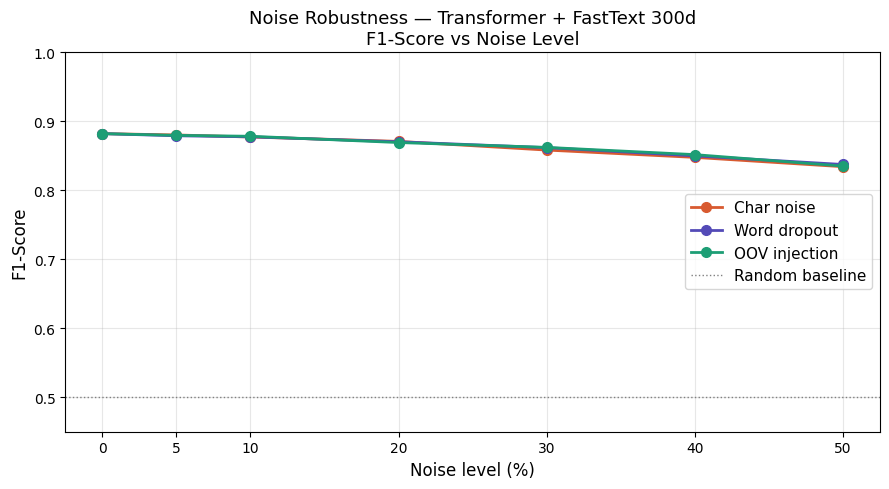


Noise type           Clean    @10%    @30%   Drop@50%
--------------------------------------------------
Char noise          0.8819  0.8770  0.8581    +0.0479
Word dropout        0.8819  0.8773  0.8616    +0.0447
OOV injection       0.8819  0.8781  0.8620    +0.0470


In [16]:
noise_levels  = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
noise_configs = [
    ('Char noise',    char_noise,    '#D85A30'),
    ('Word dropout',  word_dropout,  '#534AB7'),
    ('OOV injection', oov_inject,    '#1D9E75'),
]

snr_results = {}

for label, fn, _ in noise_configs:
    f1s = []
    print(f'Running {label}...')
    for lvl in noise_levels:
        X_noisy      = encode_noisy(X_test_clean, fn, lvl)
        y_prob_noisy = predict_probs(model, X_noisy)
        y_pred_noisy = (y_prob_noisy > 0.5).astype(int).flatten()
        score        = f1_score(y_test, y_pred_noisy)
        f1s.append(round(score, 4))
        print(f'  {lvl:.0%} → F1={score:.4f}')
    snr_results[label] = f1s

# ── Plot SNR curves ────────────────────────────────────────────────
pct = [x * 100 for x in noise_levels]

fig, ax = plt.subplots(figsize=(9, 5))
for (label, _, color) in noise_configs:
    ax.plot(pct, snr_results[label], '-o', color=color,
            linewidth=2, markersize=7, label=label)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')
ax.set_xlabel('Noise level (%)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Noise Robustness — Transformer + FastText 300d\n'
             'F1-Score vs Noise Level', fontsize=13)
ax.set_ylim(0.45, 1.00)
ax.set_xticks(pct)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Degradation table ──────────────────────────────────────────────
print(f'\n{"Noise type":<18} {"Clean":>7} {"@10%":>7} {"@30%":>7} {"Drop@50%":>10}')
print('-' * 50)
for label, _, _ in noise_configs:
    vals = snr_results[label]
    print(f'{label:<18} {vals[0]:>7.4f} {vals[2]:>7.4f} '
          f'{vals[4]:>7.4f} {vals[0]-vals[-1]:>+10.4f}')

## Step 9 — Interpretability

### 9A. LIME — Local Explanation
LIME asks: *"which words in this specific review pushed the model toward Positive or Negative?"*
It creates hundreds of modified versions (words removed), runs them through the model, and fits a simple linear model to find which words mattered most.

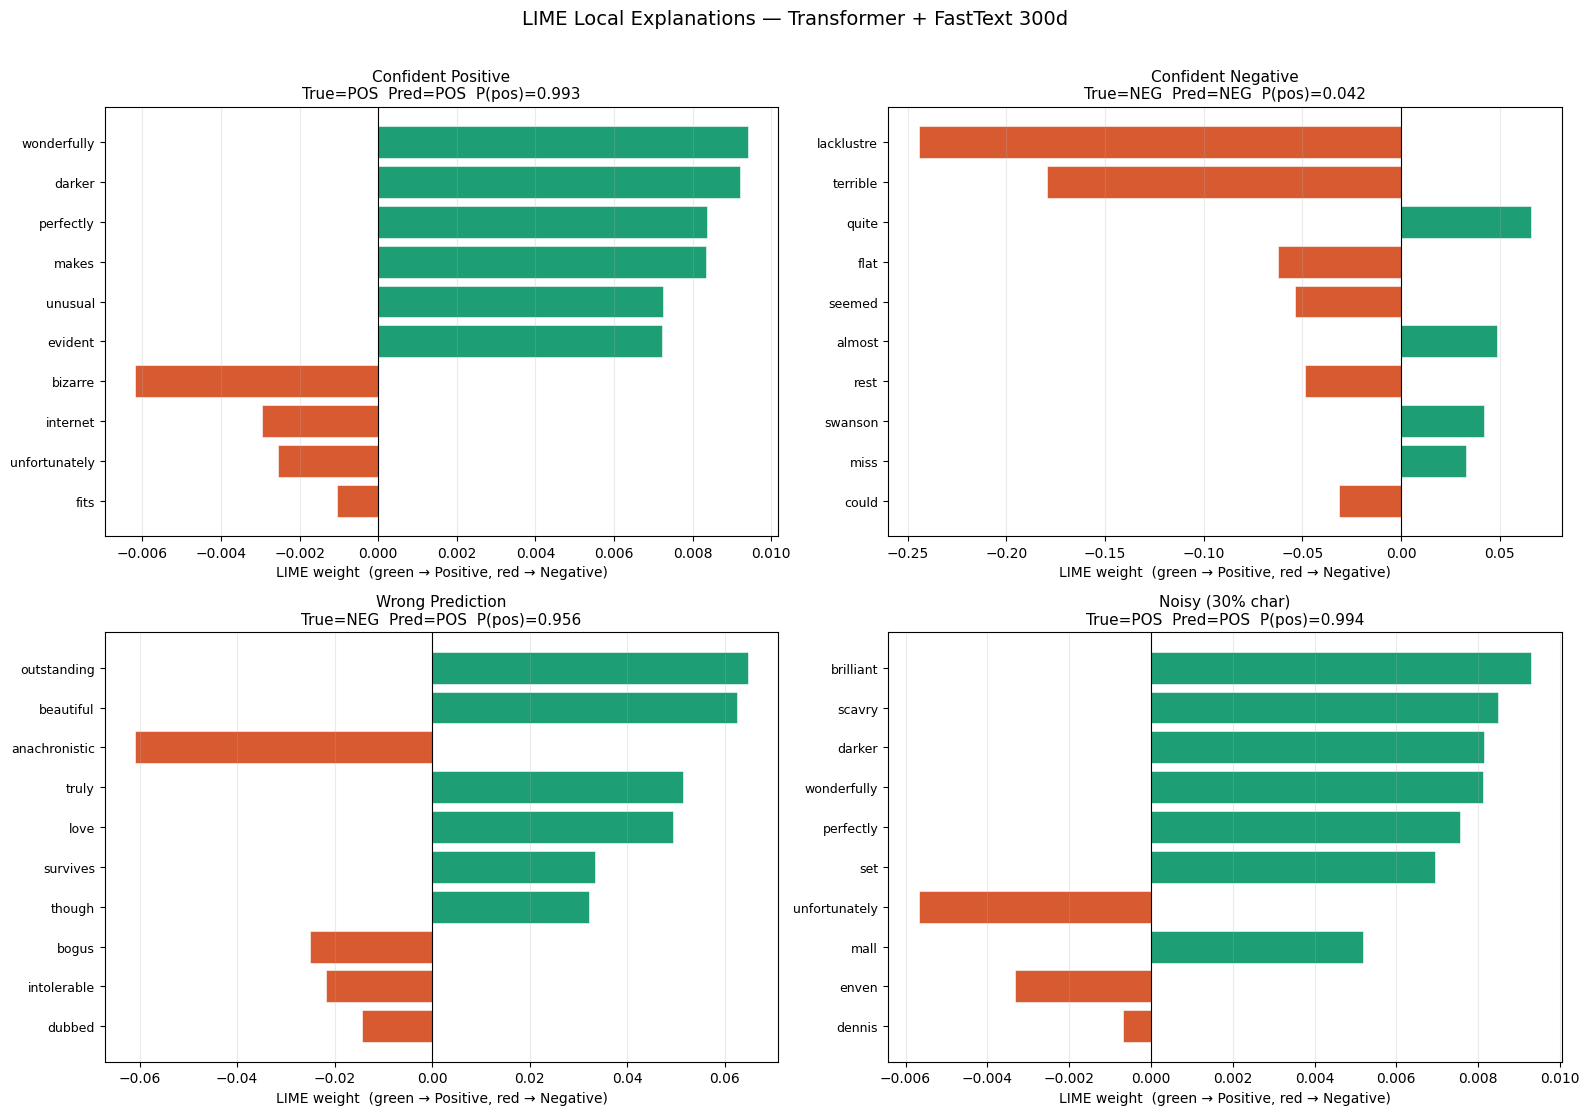

In [17]:
def pipeline_predict(texts):
    """LIME needs a function: list of raw strings → 2-column probabilities."""
    seqs   = tokenizer.texts_to_sequences([clean_text(t) for t in texts])
    padded = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = predict_probs(model, padded).flatten()
    return np.column_stack([1 - probs, probs])  # [P(neg), P(pos)]

explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

# Pick 4 examples: confident positive, confident negative,
#                  one wrong prediction, one noisy version
idx_pos   = np.where((y_test == 1) & (y_prob > 0.88))[0][0]
idx_neg   = np.where((y_test == 0) & (y_prob < 0.12))[0][0]
idx_wrong = np.where(y_pred != y_test)[0][0]
noisy_txt = char_noise(X_test_clean[idx_pos], 0.30)

samples = [
    ('Confident Positive', X_test_clean[idx_pos],   y_test[idx_pos]),
    ('Confident Negative', X_test_clean[idx_neg],   y_test[idx_neg]),
    ('Wrong Prediction',   X_test_clean[idx_wrong],  y_test[idx_wrong]),
    ('Noisy (30% char)',   noisy_txt,                y_test[idx_pos]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (title, text, true_lbl) in zip(axes, samples):
    p   = pipeline_predict([text])[0][1]
    exp = explainer.explain_instance(text, pipeline_predict,
                                      num_features=10, num_samples=400)
    pairs    = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:10]
    words_   , weights_ = zip(*pairs)

    colors_ = ['#1D9E75' if s > 0 else '#D85A30' for s in weights_]
    ax.barh(range(len(words_)), weights_, color=colors_,
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(words_)))
    ax.set_yticklabels(words_, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME weight  (green → Positive, red → Negative)')
    ax.set_title(
        f'{title}\n'
        f'True={"POS" if true_lbl==1 else "NEG"}  '
        f'Pred={"POS" if p>0.5 else "NEG"}  P(pos)={p:.3f}',
        fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('LIME Local Explanations — Transformer + FastText 300d',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9B. t-SNE — FastText Vector Space
Compresses 300-dimensional FastText vectors to 2D so we can *see* that positive words cluster together and negative words cluster apart. This visually proves that FastText gives the model meaningful word geometry — even better separation than GloVe due to higher dimensionality.

Words found in FastText: 45/45


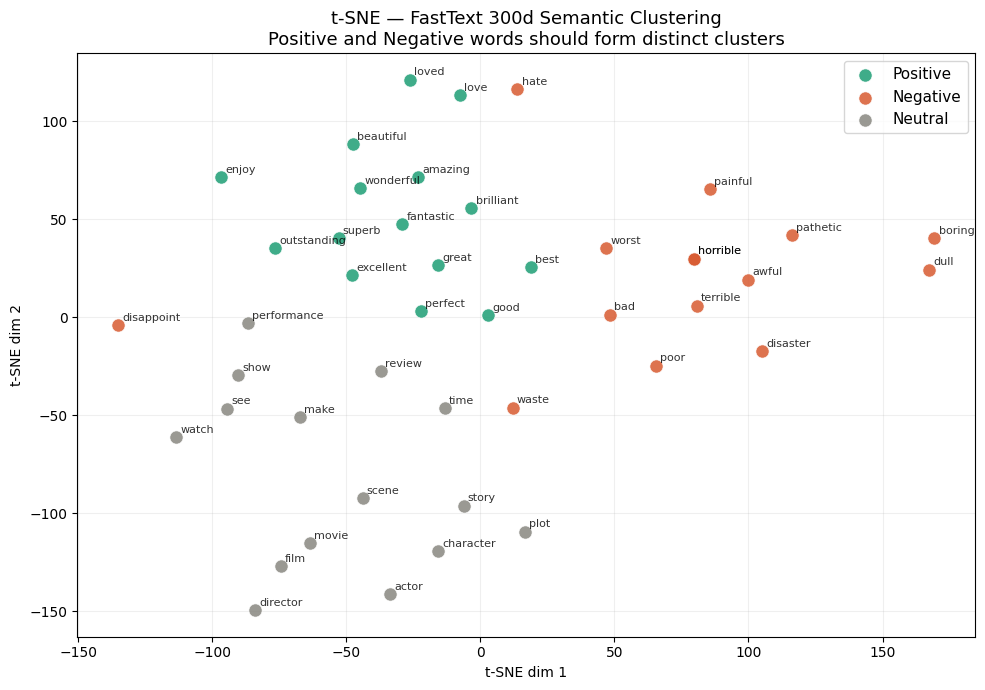

In [18]:
from sklearn.manifold import TSNE

sentiment_words = {
    'positive': ['good','great','excellent','amazing','brilliant',
                 'wonderful','love','best','perfect','fantastic',
                 'outstanding','superb','enjoy','beautiful','loved'],
    'negative': ['bad','terrible','awful','horrible','boring',
                 'hate','worst','poor','dull','disappoint',
                 'waste','painful','disaster','pathetic','horrible'],
    'neutral' : ['film','movie','watch','scene','story','actor',
                 'plot','time','make','show','see','character',
                 'review','performance','director']
}
color_map = {'positive':'#1D9E75', 'negative':'#D85A30', 'neutral':'#888780'}

word_list, vectors, cat_list = [], [], []
for cat, words in sentiment_words.items():
    for w in words:
        if w in fasttext_vectors:
            word_list.append(w)
            vectors.append(fasttext_vectors[w])
            cat_list.append(cat)

print(f'Words found in FastText: {len(word_list)}/{sum(len(v) for v in sentiment_words.values())}')

X_vecs = np.array(vectors)
tsne   = TSNE(n_components=2, perplexity=12, max_iter=1500, random_state=42)
X_2d   = tsne.fit_transform(X_vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for cat, color in color_map.items():
    mask = [i for i, c in enumerate(cat_list) if c == cat]
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, s=90,
               alpha=0.85, label=cat.capitalize(),
               edgecolors='white', linewidths=0.5, zorder=3)
    for i in mask:
        ax.annotate(word_list[i], (X_2d[i,0], X_2d[i,1]),
                    fontsize=8, alpha=0.8,
                    xytext=(3, 3), textcoords='offset points')

ax.set_title('t-SNE — FastText 300d Semantic Clustering\n'
             'Positive and Negative words should form distinct clusters',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

## Step 10 — Final Summary

        FINAL SUMMARY — Transformer + FastText 300d on IMDb
                     F1-Score Accuracy Precision  Recall
Condition                                               
Clean test set         0.8819    0.878    0.8543  0.9113
Char noise @ 10%       0.8770        —         —       —
Char noise @ 30%       0.8581        —         —       —
Word dropout @ 10%     0.8773        —         —       —
Word dropout @ 30%     0.8616        —         —       —
OOV injection @ 10%    0.8781        —         —       —
OOV injection @ 30%    0.8620        —         —       —


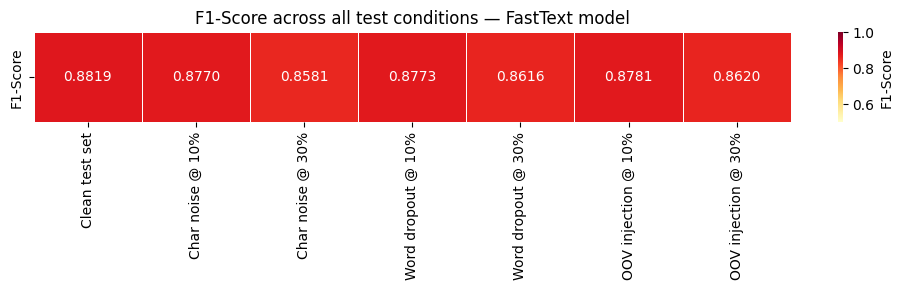


Project complete ✓
  Accuracy  (primary) : 0.8780  (87.80%)
  F1-Score            : 0.8819
  AUC-ROC             : 0.9520
  Target (>90%)       : ✗ not reached


In [19]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

rows = []
rows.append({
    'Condition' : 'Clean test set',
    'F1-Score'  : round(f1,  4),
    'Accuracy'  : round(acc, 4),
    'Precision' : round(precision_score(y_test, y_pred), 4),
    'Recall'    : round(recall_score(y_test, y_pred),    4),
})

for label, fn, _ in noise_configs:
    for lvl_idx, lvl_pct in [(2, '10%'), (4, '30%')]:
        rows.append({
            'Condition' : f'{label} @ {lvl_pct}',
            'F1-Score'  : snr_results[label][lvl_idx],
            'Accuracy'  : '—',
            'Precision' : '—',
            'Recall'    : '—',
        })

df = pd.DataFrame(rows).set_index('Condition')

print('=' * 74)
print('        FINAL SUMMARY — Transformer + FastText 300d on IMDb')
print('=' * 74)
print(df.to_string())
print('=' * 74)

# Heatmap on F1-Score column
fig, ax = plt.subplots(figsize=(10, 3))
numeric = df[['F1-Score']].apply(pd.to_numeric, errors='coerce').dropna()
sns.heatmap(numeric.T, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-Score'})
ax.set_title('F1-Score across all test conditions — FastText model', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nProject complete ✓')
print(f'  Accuracy  (primary) : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-Score            : {f1:.4f}')
print(f'  AUC-ROC             : {roc_auc:.4f}')
print(f'  Target (>90%)       : {"✓ ACHIEVED" if acc > 0.90 else "✗ not reached"}')